In [1]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn
! pip install scikit-learn

### 1. LOADING THE TOOLS

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


### 2. LOADING DATASET

In [3]:
df = pd.read_csv(r"C:\Users\Saran\Downloads\insurance.csv.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 3. FINDING THE SHAPE AND MISSING VALUES

In [6]:
df.shape

(1338, 7)

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
print("Average insurance charge: $", round(df['charges'].mean(), 2))
print("Average age of people   :", round(df['age'].mean(), 1), "years")

Average insurance charge: $ 13270.42
Average age of people   : 39.2 years


### 4. AGE VS INSURANCE CHARGES

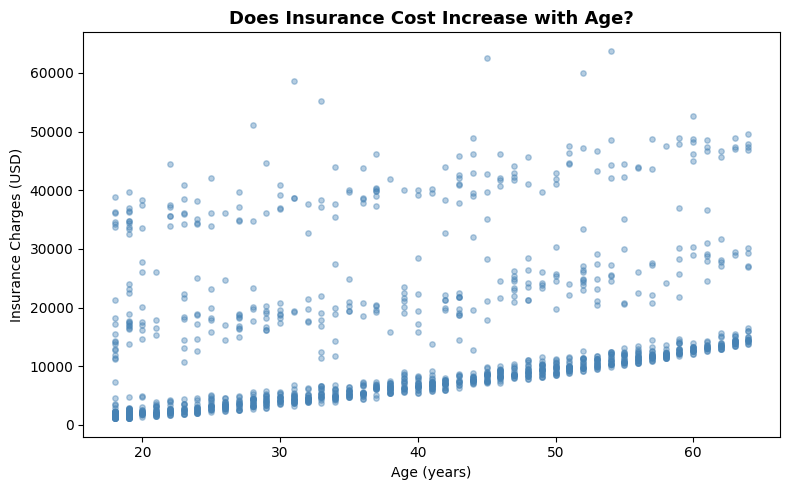

📌 You can see a mild upward trend — older people tend to pay more.


In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['charges'], color='steelblue', alpha=0.4, s=15)

plt.title('Does Insurance Cost Increase with Age?', fontsize=13, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Insurance Charges (USD)')

plt.tight_layout()
plt.show()

print("📌 You can see a mild upward trend — older people tend to pay more.")


### 5. BUILDING PREDICTION MODEL

In [10]:
from sklearn.model_selection import train_test_split

X = df[['age']]
y = df['charges']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data : {len(X_train)} people")
print(f"Testing data  : {len(X_test)} people")


model = LinearRegression()
model.fit(X_train, y_train)

print()
print("✅ Model trained successfully!")
print()


print("📐 Prediction Formula:")
print(f"   Insurance Cost = {model.intercept_:,.0f} + {model.coef_[0]:.0f} × Age")
print()
print(f"   ➡ Every 1 year older = ~${model.coef_[0]:.0f} more in insurance charges")

Training data : 1070 people
Testing data  : 268 people

✅ Model trained successfully!

📐 Prediction Formula:
   Insurance Cost = 3,877 + 241 × Age

   ➡ Every 1 year older = ~$241 more in insurance charges


### 6. MAKING PREDICTION LINE

In [11]:
import numpy as np

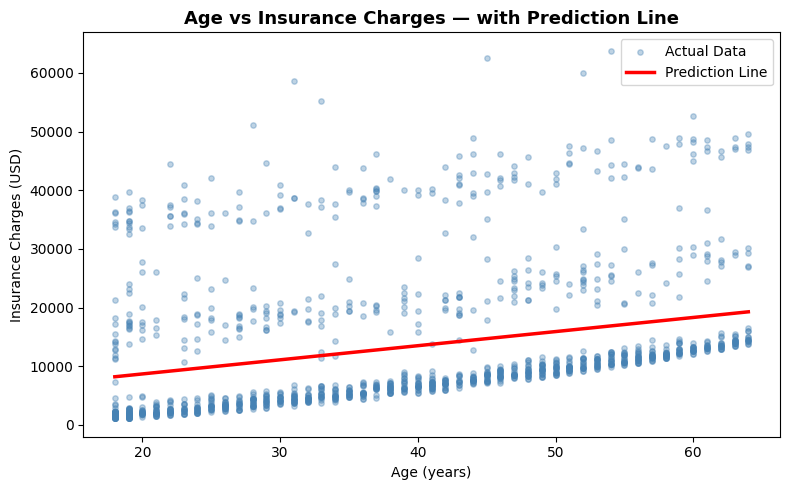

📌 The red line is our model's best guess for any given age.


In [13]:
age_range = pd.DataFrame(
    np.linspace(18, 64, 100),
    columns=['age']
)

predicted_line = model.predict(age_range)

plt.figure(figsize=(8, 5))

plt.scatter(df['age'], df['charges'],
            color='steelblue',
            alpha=0.35,
            s=15,
            label='Actual Data')

plt.plot(age_range, predicted_line,
         color='red',
         linewidth=2.5,
         label='Prediction Line')

plt.title('Age vs Insurance Charges — with Prediction Line',
          fontsize=13,
          fontweight='bold')

plt.xlabel('Age (years)')
plt.ylabel('Insurance Charges (USD)')

plt.legend()
plt.tight_layout()
plt.show()

print("📌 The red line is our model's best guess for any given age.")

### 7. MODEL ACCURACY

In [14]:
y_pred = model.predict(X_test)


r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=" * 38)
print("     MODEL ACCURACY RESULTS")
print("=" * 38)
print(f"  R² Score : {r2:.2f}  ({r2*100:.1f}% accuracy)")
print(f"  MAE      : ${mae:,.0f} average error")
print("=" * 38)
print()
print("📌 What this means in plain English:")
print(f"   Age explains {r2*100:.1f}% of why insurance costs vary.")
print(f"   On average, our prediction is off by ${mae:,.0f}.")
print()
print("   This sounds low, but it's NORMAL for a 1-variable model.")
print("   Smoking, BMI, and family size also affect costs —")
print("   but we only used age here (Simple = 1 variable).")

     MODEL ACCURACY RESULTS
  R² Score : 0.12  (12.4% accuracy)
  MAE      : $9,173 average error

📌 What this means in plain English:
   Age explains 12.4% of why insurance costs vary.
   On average, our prediction is off by $9,173.

   This sounds low, but it's NORMAL for a 1-variable model.
   Smoking, BMI, and family size also affect costs —
   but we only used age here (Simple = 1 variable).


### SELF PREDICTION TEST

In [16]:
my_age = 22

my_age_df = pd.DataFrame([[my_age]], columns=['age'])

predicted_cost = model.predict(my_age_df)[0]

print(f"A {my_age}-year-old person is predicted to pay: ${predicted_cost:,.2f} per year")
print()

print("Predicted insurance costs by age:")
print("-" * 32)

for age in [20, 30, 40, 50, 60]:

    age_df = pd.DataFrame([[age]], columns=['age'])

    cost = model.predict(age_df)[0]

    print(f"  Age {age}  →  ${cost:,.0f}")

A 22-year-old person is predicted to pay: $9,170.05 per year

Predicted insurance costs by age:
--------------------------------
  Age 20  →  $8,689
  Age 30  →  $11,095
  Age 40  →  $13,501
  Age 50  →  $15,907
  Age 60  →  $18,313


### SMOKER VS NON SMOKER

Average Annual Insurance Cost:
  🚬 Smoker      : $32,050
  🚭 Non-Smoker  : $8,434
  📊 Smokers pay 3.8x more!


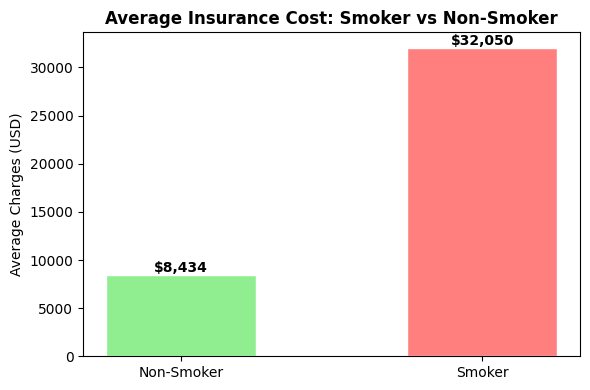

In [17]:
avg_smoker    = df[df['smoker'] == 'yes']['charges'].mean()
avg_nonsmoker = df[df['smoker'] == 'no']['charges'].mean()

print("Average Annual Insurance Cost:")
print(f"  🚬 Smoker      : ${avg_smoker:,.0f}")
print(f"  🚭 Non-Smoker  : ${avg_nonsmoker:,.0f}")
print(f"  📊 Smokers pay {avg_smoker/avg_nonsmoker:.1f}x more!")

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Non-Smoker', 'Smoker'], [avg_nonsmoker, avg_smoker],
        color=['#90EE90', '#FF7F7F'], edgecolor='white', width=0.5)
plt.title('Average Insurance Cost: Smoker vs Non-Smoker', fontweight='bold')
plt.ylabel('Average Charges (USD)')
for i, val in enumerate([avg_nonsmoker, avg_smoker]):
    plt.text(i, val + 300, f'${val:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()